In [12]:
import sys
import os
from pathlib import Path

_project_root = Path('..').resolve()
os.environ.setdefault('DATA_CATALOG_PATH', str(_project_root / 'data' / 'catalog'))
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from cyber_trader.data.catalog import get_catalog
from cyber_trader.config import get_settings
from cyber_trader.indicators.factor_engine import (
    BollingerFactor, RSIFactor, StochasticMRFactor
)

catalog  = get_catalog()
settings = get_settings()
print(f'Catalog: {settings.data_catalog_path}')

Catalog: /Users/bytedance/github_personal/cyber_trader/data/catalog


In [13]:
# ═══════════════════════════════════════════════
#  修改这里来切换时间段 / 品种
# ═══════════════════════════════════════════════
INSTRUMENT = 'ETH-USDT-SWAP.OKX'
TIMEFRAME  = '4h'           # 15m | 1h | 4h | 1d
START      = '2026-01-01'
END        = '2026-06-06'

# MR 因子参数（与 backtest_1h_mr.yaml 保持一致）
BB_PERIOD     = 20
BB_K          = 2.0
BB_WEIGHT     = 0.45
RSI_PERIOD    = 14
RSI_WEIGHT    = 0.35
STOCH_K       = 14
STOCH_D       = 3
STOCH_SLOW    = 3
STOCH_WEIGHT  = 0.20

# 入场阈值（用于在图上画参考线）
SHORT_THRESHOLD = -0.25
LONG_THRESHOLD  =  0.50
# ═══════════════════════════════════════════════

In [14]:
from cyber_trader.data.okx_downloader import timeframe_to_bar_type

BAR_TYPE = timeframe_to_bar_type(INSTRUMENT, TIMEFRAME)
start_ts = pd.Timestamp(START, tz='UTC')
end_ts   = pd.Timestamp(END,   tz='UTC') + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
start_ns, end_ns = int(start_ts.value), int(end_ts.value)

print(f'Instrument : {INSTRUMENT}  [{TIMEFRAME}]')
print(f'Range      : {start_ts.date()}  →  {end_ts.date()}')

bb_f    = BollingerFactor(period=BB_PERIOD, k=BB_K,        weight=BB_WEIGHT)
rsi_f   = RSIFactor(period=RSI_PERIOD,                     weight=RSI_WEIGHT)
stch_f  = StochasticMRFactor(period_k=STOCH_K, period_d=STOCH_D,
                              slowing=STOCH_SLOW,           weight=STOCH_WEIGHT)

print('Loading bars from catalog...')
all_bars = catalog.bars([BAR_TYPE])
print(f'Total in catalog: {len(all_bars):,}')

rows = []
for bar in all_bars:
    bb_f.update(bar)
    rsi_f.update(bar)
    stch_f.update(bar)

    # BB 原始值（上中下轨）
    bb_upper = bb_f._bb.upper  if bb_f.is_initialized else None
    bb_mid   = bb_f._bb.middle if bb_f.is_initialized else None
    bb_lower = bb_f._bb.lower  if bb_f.is_initialized else None

    # RSI 原始值（0-100）
    rsi_raw  = rsi_f._rsi.value if rsi_f.is_initialized else None

    # Stochastic %K 原始值（0-100）
    stk_raw  = stch_f._stoch.value_k if stch_f.is_initialized else None

    # 复合因子得分（加权平均）
    total_w = sum(abs(f.weight) for f in [bb_f, rsi_f, stch_f] if f.is_initialized)
    composite = (
        sum(f.weighted_score() for f in [bb_f, rsi_f, stch_f] if f.is_initialized) / total_w
        if total_w > 0 else 0.0
    )

    if start_ns <= bar.ts_event <= end_ns:
        rows.append({
            'ts':        pd.Timestamp(bar.ts_event, unit='ns', tz='UTC'),
            'open':      bar.open.as_double(),
            'high':      bar.high.as_double(),
            'low':       bar.low.as_double(),
            'close':     bar.close.as_double(),
            'bb_upper':  bb_upper,
            'bb_mid':    bb_mid,
            'bb_lower':  bb_lower,
            'bb_score':  bb_f.score()   if bb_f.is_initialized   else 0.0,
            'rsi_raw':   rsi_raw,
            'rsi_score': rsi_f.score()  if rsi_f.is_initialized  else 0.0,
            'stk_raw':   stk_raw,
            'stk_score': stch_f.score() if stch_f.is_initialized else 0.0,
            'composite': composite,
        })

if not rows:
    raise ValueError(f'No bars found for {INSTRUMENT} [{TIMEFRAME}] in {START} ~ {END}.')

df = pd.DataFrame(rows).set_index('ts')
print(f'Plotting    : {len(df):,} bars  [{df.index[0]}  →  {df.index[-1]}]')
df.head()

Instrument : ETH-USDT-SWAP.OKX  [4h]
Range      : 2026-01-01  →  2026-06-06
Loading bars from catalog...
Total in catalog: 3,115
Plotting    : 926 bars  [2026-01-01 00:00:00+00:00  →  2026-06-04 04:00:00+00:00]


,open,high,low,close,bb_upper,bb_mid,bb_lower,bb_score,rsi_raw,rsi_score,stk_raw,stk_score,composite
ts,,,,,,,,,,,,,
2026-01-01 00:00:00+00:00,2970.09,2983.73,2961.38,2970.23,3019.629290,2967.740167,2915.851044,-0.047984,0.494052,0.990119,52.724559,-0.054491,0.314051
2026-01-01 04:00:00+00:00,2970.23,2987.99,2970.00,2979.15,3019.875654,2969.890833,2919.906012,-0.185240,0.543285,0.989134,54.283592,-0.085672,0.245705
2026-01-01 08:00:00+00:00,2979.15,2982.60,2972.00,2977.36,3020.179741,2971.558167,2922.936593,-0.119326,0.531314,0.989374,54.251759,-0.085035,0.275577
2026-01-01 12:00:00+00:00,2977.35,2991.76,2976.72,2987.78,3015.884719,2970.267333,2924.649948,-0.383903,0.591739,0.988165,55.390522,-0.107810,0.151539
2026-01-01 16:00:00+00:00,2987.78,2994.45,2975.12,2988.47,3006.540934,2968.215500,2929.890066,-0.528487,0.595721,0.988086,54.486446,-0.089729,0.090065


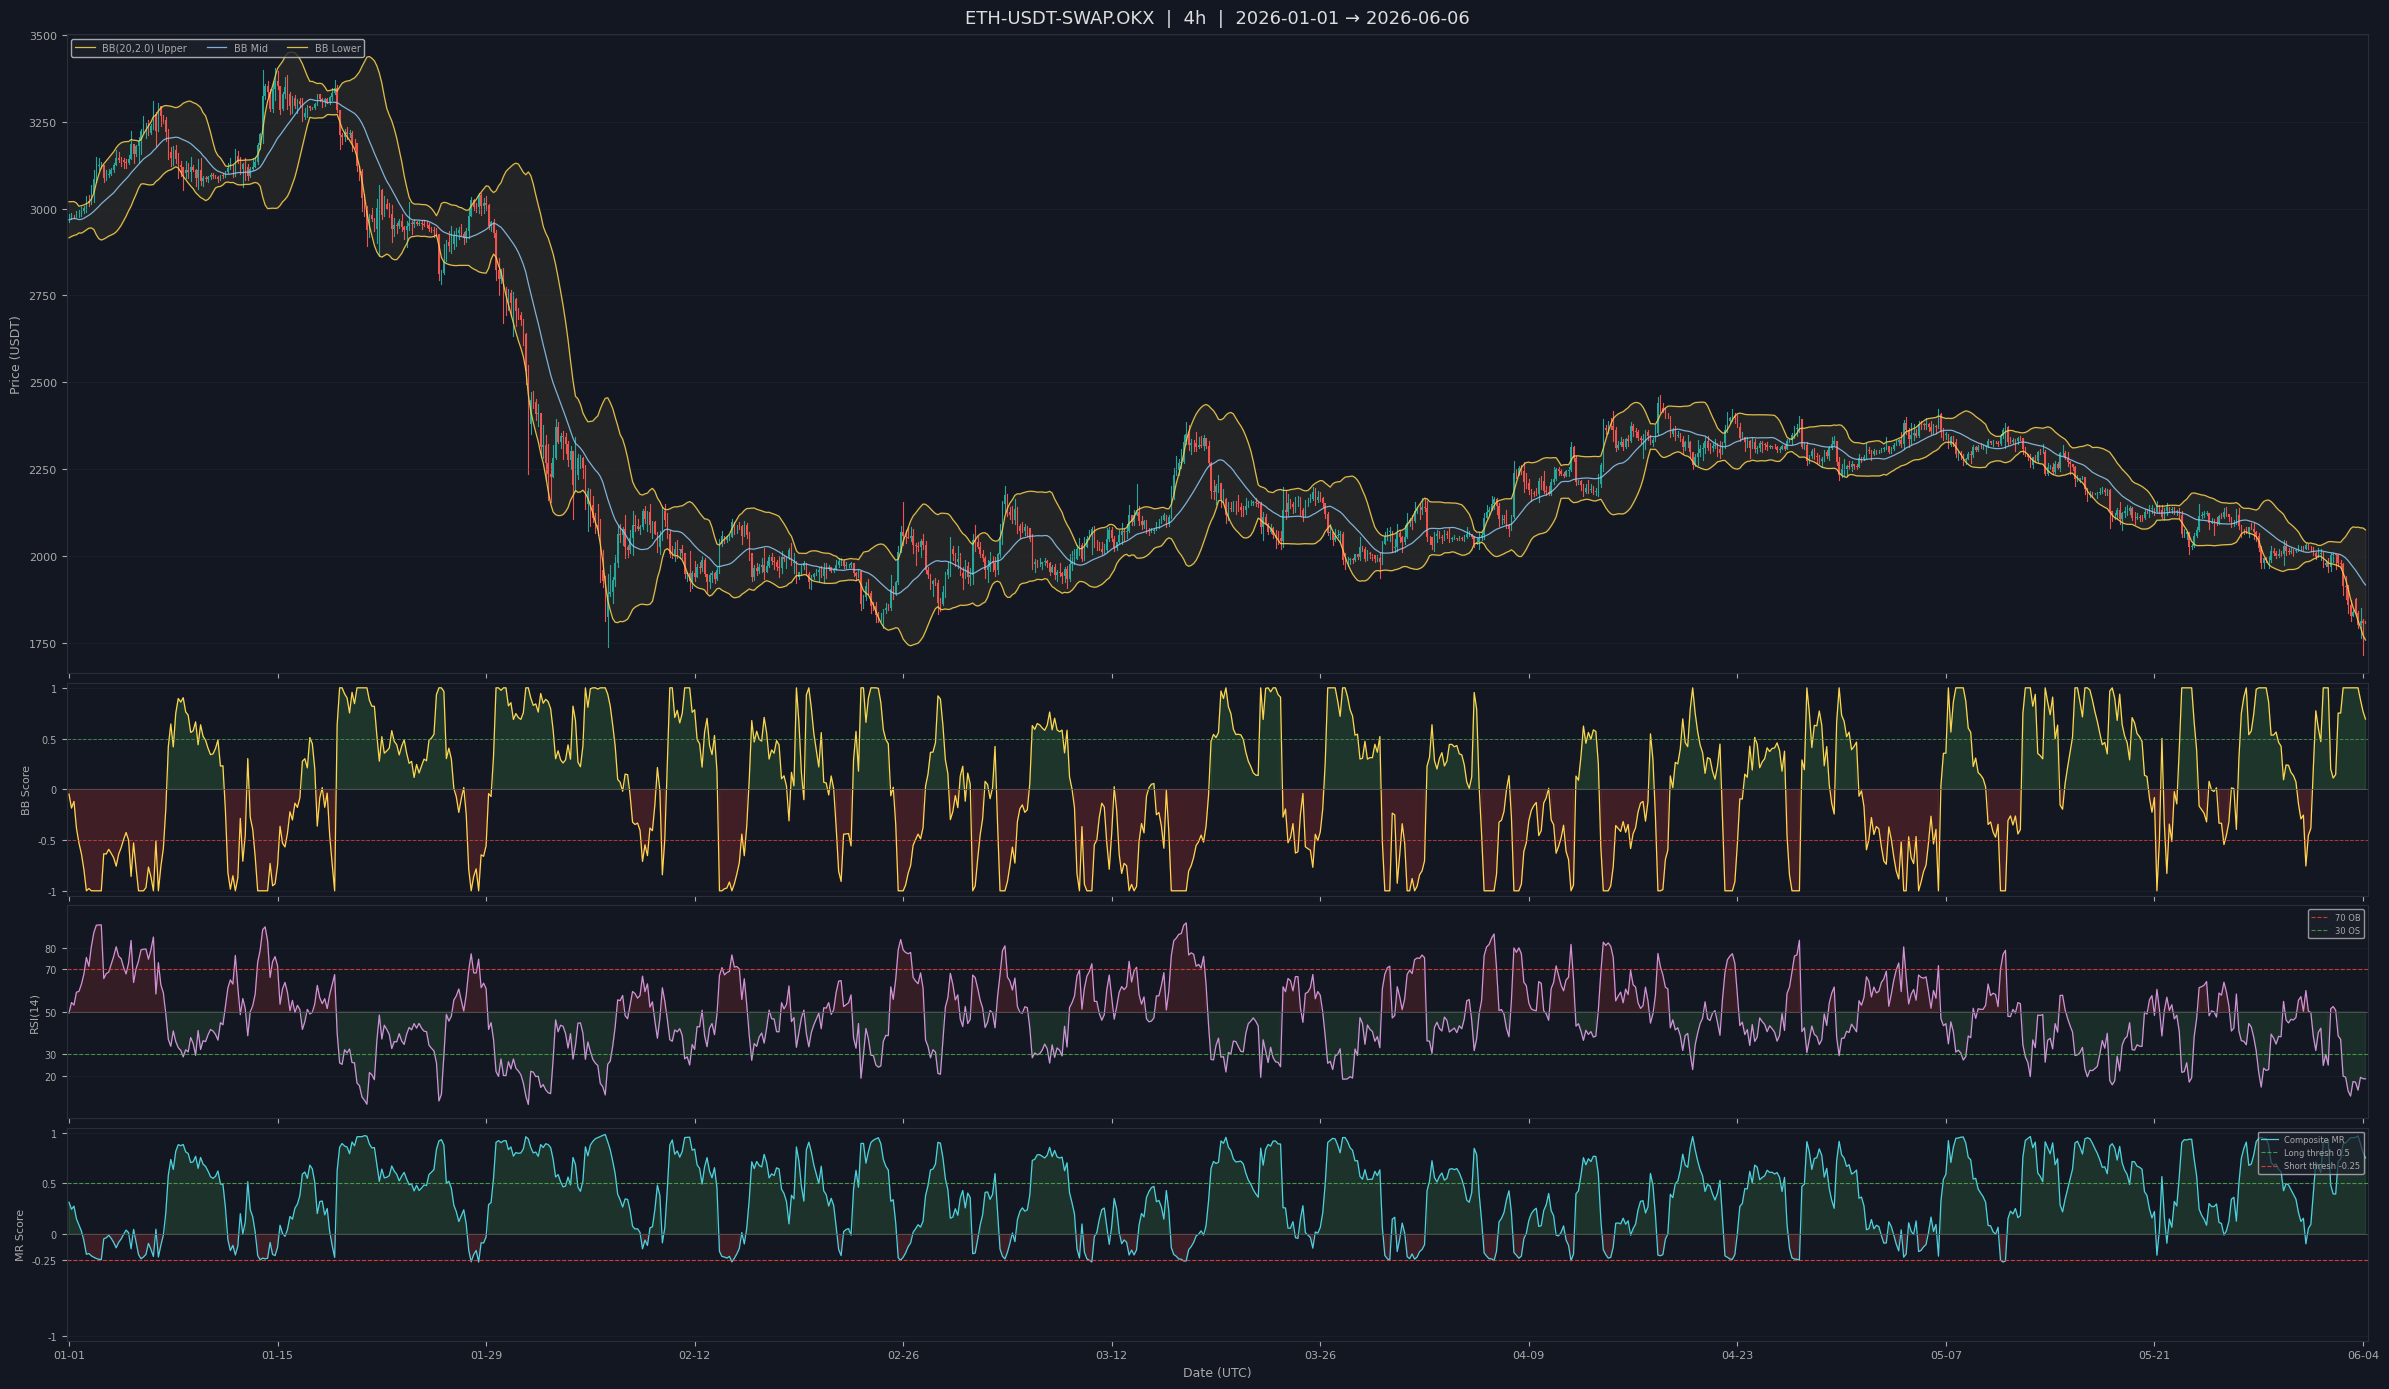

Done — 926 bars  →  eth_4h_mr_2026-01-01_2026-06-06.png


In [15]:
n = len(df)

# ── X 轴刻度 ─────────────────────────────────────────────────────────────────
_tf_bars = {'15m': 1, '1h': 4, '4h': 16, '1d': 96}
bars_per_day = 96 // _tf_bars.get(TIMEFRAME, 1)

if n <= 120:
    tick_step = max(1, bars_per_day // 2)      # 2天一格
elif n <= 500:
    tick_step = bars_per_day * 7               # 1周一格
elif n <= 2000:
    tick_step = bars_per_day * 14              # 2周一格
else:
    tick_step = bars_per_day * 30              # 1月一格

tick_pos    = list(range(0, n, tick_step))
tick_fmt    = '%m-%d' if n <= 2000 else '%Y-%m'
tick_labels = [df.index[i].strftime(tick_fmt) for i in tick_pos]

# ── Layout ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    4, 1, figsize=(24, 14), sharex=True,
    gridspec_kw={'height_ratios': [3, 1, 1, 1]}
)
ax_c, ax_bb, ax_rsi, ax_comp = axes
fig.patch.set_facecolor('#131722')
for ax in axes:
    ax.set_facecolor('#131722')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2e39')

# ── Candlestick ───────────────────────────────────────────────────────────────
width = 0.6
bull  = '#26a69a'
bear  = '#ef5350'

for i, (ts, row) in enumerate(df.iterrows()):
    color = bull if row['close'] >= row['open'] else bear
    safe_high = min(row['high'], row['close'] * 1.5)
    safe_low  = max(row['low'],  row['close'] * 0.5)
    ax_c.plot([i, i], [safe_low, safe_high], color=color, linewidth=0.8, zorder=1)
    bot = min(row['open'], row['close'])
    h   = max(abs(row['close'] - row['open']), row['close'] * 1e-4)
    ax_c.add_patch(mpatches.Rectangle(
        (i - width / 2, bot), width, h,
        facecolor=color, edgecolor='none', zorder=2
    ))

# ── BB 带叠加在K线上 ──────────────────────────────────────────────────────────
x = np.arange(n)
bb_u = df['bb_upper'].values.astype(float)
bb_m = df['bb_mid'].values.astype(float)
bb_l = df['bb_lower'].values.astype(float)

ax_c.plot(x, bb_u, color='#FFD54F', linewidth=0.9, alpha=0.85, zorder=3, label=f'BB({BB_PERIOD},{BB_K}) Upper')
ax_c.plot(x, bb_m, color='#90CAF9', linewidth=0.9, alpha=0.85, zorder=3, label='BB Mid')
ax_c.plot(x, bb_l, color='#FFD54F', linewidth=0.9, alpha=0.85, zorder=3, label='BB Lower')
ax_c.fill_between(x, bb_u, bb_l, alpha=0.07, color='#FFD54F', zorder=0)

ax_c.set_xlim(-1, n)
price_min = df[['low', 'bb_lower']].min(skipna=True).min()
price_max = df[['high', 'bb_upper']].max(skipna=True).max()
margin = (price_max - price_min) * 0.03
ax_c.set_ylim(price_min - margin, price_max + margin)
ax_c.set_ylabel('Price (USDT)', color='#aaaaaa', fontsize=9)
ax_c.set_title(
    f'{INSTRUMENT}  |  {TIMEFRAME}  |  {START} → {END}',
    color='#dddddd', fontsize=13, pad=8
)
ax_c.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
ax_c.legend(loc='upper left', fontsize=7, facecolor='#1e222d',
            labelcolor='#aaaaaa', framealpha=0.8, ncol=3)

# ── BB 因子得分面板 ───────────────────────────────────────────────────────────
bb_scores = df['bb_score'].values
ax_bb.plot(x, bb_scores, color='#FFD54F', linewidth=0.9, zorder=2)
ax_bb.fill_between(x, bb_scores, 0, where=(bb_scores >= 0), alpha=0.2, color='#4CAF50', zorder=1)
ax_bb.fill_between(x, bb_scores, 0, where=(bb_scores <  0), alpha=0.2, color='#F44336', zorder=1)
ax_bb.axhline(0,     color='#555555', linewidth=0.6)
ax_bb.axhline( 0.5,  color='#4CAF50', linewidth=0.7, linestyle='--', alpha=0.7)
ax_bb.axhline(-0.5,  color='#F44336', linewidth=0.7, linestyle='--', alpha=0.7)
ax_bb.set_ylim(-1.05, 1.05)
ax_bb.set_ylabel(f'BB Score', color='#aaaaaa', fontsize=8)
ax_bb.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
ax_bb.set_yticks([-1, -0.5, 0, 0.5, 1])
ax_bb.set_yticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=7, color='#aaaaaa')

# ── RSI 面板（标准 0-100 刻度）────────────────────────────────────────────────
# nautilus RelativeStrengthIndex.value 返回 [0,1]，乘以 100 转为标准刻度
rsi_pct = df['rsi_raw'].values.astype(float) * 100
ax_rsi.plot(x, rsi_pct, color='#CE93D8', linewidth=0.9, zorder=2)
ax_rsi.fill_between(x, rsi_pct, 50, where=(rsi_pct < 50), alpha=0.15, color='#4CAF50', zorder=1)
ax_rsi.fill_between(x, rsi_pct, 50, where=(rsi_pct > 50), alpha=0.15, color='#F44336', zorder=1)
ax_rsi.axhline(70, color='#F44336', linewidth=0.8, linestyle='--', alpha=0.8, label='70 OB')
ax_rsi.axhline(50, color='#555555', linewidth=0.6)
ax_rsi.axhline(30, color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.8, label='30 OS')
ax_rsi.set_ylim(0, 100)
ax_rsi.set_ylabel(f'RSI({RSI_PERIOD})', color='#aaaaaa', fontsize=8)
ax_rsi.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
ax_rsi.set_yticks([20, 30, 50, 70, 80])
ax_rsi.set_yticklabels(['20', '30', '50', '70', '80'], fontsize=7, color='#aaaaaa')
ax_rsi.legend(loc='upper right', fontsize=6, facecolor='#1e222d',
              labelcolor='#aaaaaa', framealpha=0.7)

# ── 复合 MR 得分面板 ──────────────────────────────────────────────────────────
comp = df['composite'].values
ax_comp.plot(x, comp, color='#4DD0E1', linewidth=0.9, zorder=2, label='Composite MR')
ax_comp.fill_between(x, comp, 0, where=(comp >= 0), alpha=0.18, color='#4CAF50', zorder=1)
ax_comp.fill_between(x, comp, 0, where=(comp <  0), alpha=0.18, color='#F44336', zorder=1)
ax_comp.axhline(0,                color='#555555', linewidth=0.6)
ax_comp.axhline(LONG_THRESHOLD,   color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.85,
                label=f'Long thresh {LONG_THRESHOLD}')
ax_comp.axhline(SHORT_THRESHOLD,  color='#F44336', linewidth=0.8, linestyle='--', alpha=0.85,
                label=f'Short thresh {SHORT_THRESHOLD}')
ax_comp.set_ylim(-1.05, 1.05)
ax_comp.set_ylabel('MR Score', color='#aaaaaa', fontsize=8)
ax_comp.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
ax_comp.set_yticks([-1, SHORT_THRESHOLD, 0, LONG_THRESHOLD, 1])
ax_comp.set_yticklabels(['-1', str(SHORT_THRESHOLD), '0', str(LONG_THRESHOLD), '1'],
                         fontsize=7, color='#aaaaaa')
ax_comp.legend(loc='upper right', fontsize=6, facecolor='#1e222d',
               labelcolor='#aaaaaa', framealpha=0.7)

# ── X 轴标签 ──────────────────────────────────────────────────────────────────
for ax in axes:
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([])
ax_comp.set_xticklabels(tick_labels, color='#aaaaaa', fontsize=8)
ax_comp.set_xlabel('Date (UTC)', color='#aaaaaa', fontsize=9)

plt.tight_layout(h_pad=0.3)
fname = f'eth_{TIMEFRAME}_mr_{START}_{END}.png'.replace(':', '-')
# plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Done — {n} bars  →  {fname}')
